# Wildfire classification and Grad-CAM

This notebook runs the same packaged code used by DVC, MLflow, the CLI, and the API. It preserves the supplied train/validation/test split, classifies test images with the validation-selected threshold, and visualizes which final DenseNet feature regions influenced each decision.

> Run from the project environment created in `README.md`. Training the full 30,250-image training set is best done on a GPU.

In [4]:
!unzip /content/wildfire_project.zip -d /content/wildfire_project

Archive:  /content/wildfire_project.zip
   creating: /content/wildfire_project/wildfire_project/
  inflating: /content/wildfire_project/wildfire_project/.dockerignore  
  inflating: /content/wildfire_project/wildfire_project/.dvcignore  
   creating: /content/wildfire_project/wildfire_project/.github/
   creating: /content/wildfire_project/wildfire_project/.github/workflows/
  inflating: /content/wildfire_project/wildfire_project/.github/workflows/ci.yml  
  inflating: /content/wildfire_project/wildfire_project/.gitignore  
   creating: /content/wildfire_project/wildfire_project/datasets/
  inflating: /content/wildfire_project/wildfire_project/datasets/test.zip  
  inflating: /content/wildfire_project/wildfire_project/datasets/train.zip  
  inflating: /content/wildfire_project/wildfire_project/datasets/valid.zip  
  inflating: /content/wildfire_project/wildfire_project/docker-compose.yml  
  inflating: /content/wildfire_project/wildfire_project/Dockerfile  
  inflating: /content/wildfi

In [7]:
import os
os.listdir('/content/wildfire_project/wildfire_project')

['tests',
 '.gitignore',
 'src',
 'docker-compose.yml',
 'Dockerfile',
 'datasets',
 'notebooks',
 'params.yaml',
 'pyproject.toml',
 '.dvcignore',
 'README.md',
 'dvc.yaml',
 '.dockerignore',
 '.github',
 'MODEL_CARD.md']

In [10]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Adjusting PROJECT_ROOT to the unzipped directory
PROJECT_ROOT = Path('/content/wildfire_project/wildfire_project').resolve()

if not (PROJECT_ROOT / 'params.yaml').exists():
    raise FileNotFoundError(f'Could not find params.yaml at {PROJECT_ROOT}')

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from wildfire_ml.config import load_config
from wildfire_ml.data import prepare_data
from wildfire_ml.gradcam import load_image_batch, make_gradcam_heatmap, overlay_heatmap

config = load_config(PROJECT_ROOT / 'params.yaml')
class_names = config.section('data')['class_names']
image_size = tuple(config.section('data')['image_size'])
class_names, image_size

(['nowildfire', 'wildfire'], (224, 224))

## 1. Prepare and inspect the supplied data

The operation is safe and idempotent. On the first run it extracts about 42,850 images and verifies that every image is readable.

In [11]:
summary = prepare_data(config)
summary

{'class_names': ['nowildfire', 'wildfire'],
 'counts': {'train': {'nowildfire': 14500, 'wildfire': 15750},
  'valid': {'nowildfire': 2820, 'wildfire': 3480},
  'test': {'nowildfire': 2820, 'wildfire': 3480}},
 'total_images': 42850,
 'newly_extracted_splits': ['train', 'valid', 'test'],
 'manifest': '/content/wildfire_project/wildfire_project/data/processed/manifest.csv'}

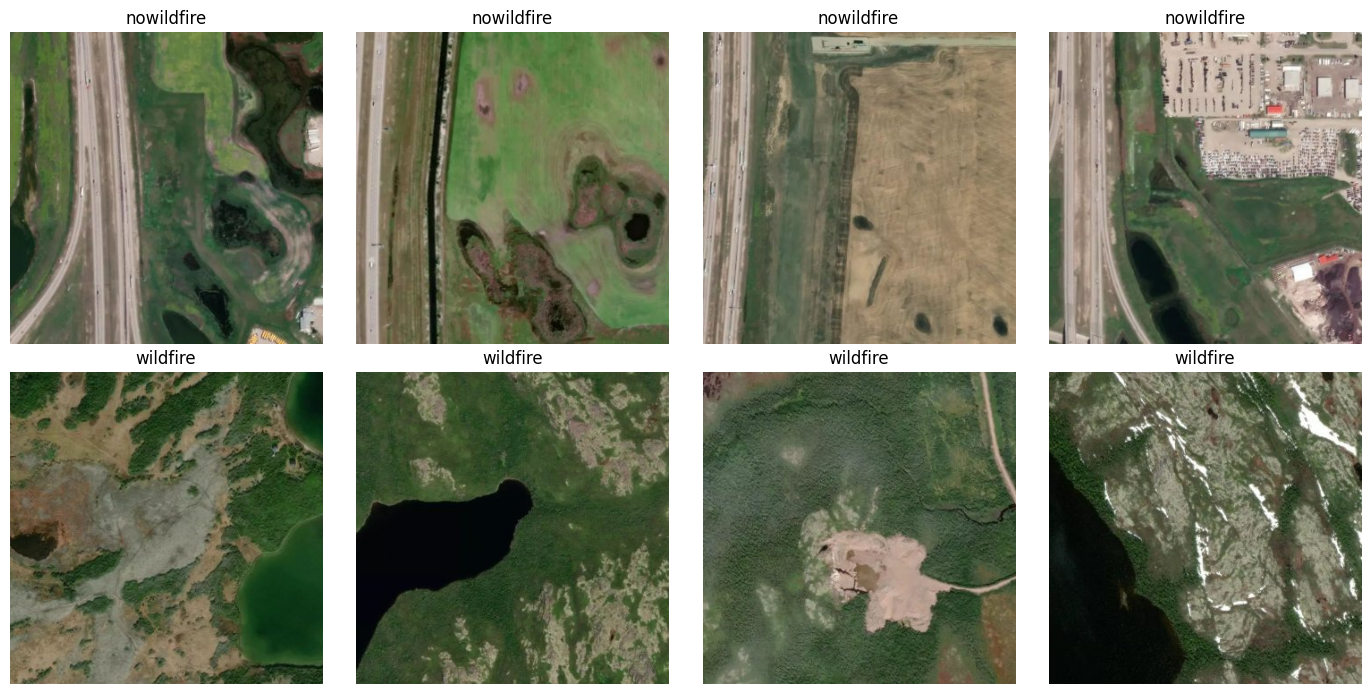

In [12]:
processed_dir = config.path('data', 'processed_dir')
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, class_name in enumerate(class_names):
    examples = sorted((processed_dir / 'train' / class_name).glob('*.jpg'))[:4]
    for axis, path in zip(axes[row], examples):
        axis.imshow(Image.open(path).convert('RGB'))
        axis.set_title(class_name)
        axis.axis('off')
plt.tight_layout()

In [16]:
import PIL.Image
from pathlib import Path

def validate_images(directory):
    print(f'Validating images in {directory}...')
    invalid_count = 0
    for img_path in Path(directory).rglob('*.jpg'):
        try:
            with PIL.Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            print(f'Corrupted image found and removed: {img_path} ({e})')
            img_path.unlink()
            invalid_count += 1
    return invalid_count

# Validate train and valid splits
processed_dir = config.path('data', 'processed_dir')
corrupted_train = validate_images(processed_dir / 'train')
corrupted_valid = validate_images(processed_dir / 'valid')

print(f'Total corrupted images removed: {corrupted_train + corrupted_valid}')

Validating images in /content/wildfire_project/wildfire_project/data/processed/train...
Validating images in /content/wildfire_project/wildfire_project/data/processed/valid...
Total corrupted images removed: 0


In [24]:
import tensorflow as tf
from pathlib import Path

def strict_tf_validation(directory):
    print(f'Strictly validating images in {directory} using TensorFlow...')
    invalid_count = 0
    for img_path in Path(directory).rglob('*.jpg'):
        try:
            img_bytes = tf.io.read_file(str(img_path))
            tf.io.decode_jpeg(img_bytes)
        except Exception as e:
            print(f'TF-incompatible image removed: {img_path}')
            img_path.unlink()
            invalid_count += 1
    return invalid_count

processed_dir = config.path('data', 'processed_dir')
# Now validating all three splits: train, valid, and test
tf_corrupted = (
    strict_tf_validation(processed_dir / 'train') +
    strict_tf_validation(processed_dir / 'valid') +
    strict_tf_validation(processed_dir / 'test')
)
print(f'Total TF-incompatible images removed: {tf_corrupted}')

Strictly validating images in /content/wildfire_project/wildfire_project/data/processed/train using TensorFlow...
Strictly validating images in /content/wildfire_project/wildfire_project/data/processed/valid using TensorFlow...
Strictly validating images in /content/wildfire_project/wildfire_project/data/processed/test using TensorFlow...
TF-incompatible image removed: /content/wildfire_project/wildfire_project/data/processed/test/wildfire/-73.15884,46.38819.jpg
Total TF-incompatible images removed: 1


## 2. Train and evaluate (optional)

Leave `RUN_TRAINING=False` when `artifacts/models/final.keras` already exists. The training call performs the frozen-head phase and controlled fine-tuning; evaluation selects F2 threshold on validation and reports the untouched test split.

In [18]:
RUN_TRAINING = True

if RUN_TRAINING:
    from wildfire_ml.training import train
    from wildfire_ml.evaluation import evaluate

    training_summary = train(config)
    evaluation_summary = evaluate(config)
    print(evaluation_summary['test'])

Found 30249 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.


Epoch 1/8
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9317 - loss: 0.2946 - pr_auc: 0.9791 - precision: 0.9314 - recall: 0.9393 - roc_auc: 0.9791
Epoch 1: val_pr_auc improved from None to 0.99512, saving model to /content/wildfire_project/wildfire_project/artifacts/models/best.weights.h5

Epoch 1: finished saving model to /content/wildfire_project/wildfire_project/artifacts/models/best.weights.h5
946/946 ━━━━━━━━━━━━━━━━━━━━ 174s 167ms/step - accuracy: 0.9465 - loss: 0.2633 - pr_auc: 0.9865 - precision: 0.9463 - recall: 0.9513 - roc_auc: 0.9866 - val_accuracy: 0.9679 - val_loss: 0.2221 - val_pr_auc: 0.9951 - val_precision: 0.9804 - val_recall: 0.9612 - val_roc_auc: 0.9945 - learning_rate: 0.0010
Epoch 2/8
945/946 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9618 - loss: 0.2303 - pr_auc: 0.9929 - precision: 0.9607 - recall: 0.9665 - roc_auc: 0.9925
Epoch 2: val_pr_auc improved from 0.99512 to 0.99583, saving model to /content/wildfire_project/wildfire_project/artifacts/

KeyboardInterrupt: 

In [22]:
RECOVER_FROM_CHECKPOINT = True
CHECKPOINT_PATH = config.path('paths', 'model_dir') / 'best.weights.h5'
# If the notebook uploader placed it elsewhere, use the actual path, for example:
# CHECKPOINT_PATH = Path('/content/best.weights.h5')  # Google Colab
# CHECKPOINT_PATH = PROJECT_ROOT / 'best.weights.h5'  # Jupyter project root

if RECOVER_FROM_CHECKPOINT:
    import tensorflow as tf
    from wildfire_ml.model import build_model

    if not CHECKPOINT_PATH.is_file():
        raise FileNotFoundError(f'Checkpoint not found: {CHECKPOINT_PATH}')
    tf.keras.backend.clear_session()
    recovery_model_config = dict(config.section('model'))
    recovery_model_config['imagenet_weights'] = None  # all values are replaced below
    recovered_model = build_model(recovery_model_config, image_size=image_size)
    recovered_model.load_weights(str(CHECKPOINT_PATH))  # strict architecture check

    final_model_path = config.path('paths', 'model_dir') / 'final.keras'
    final_model_path.parent.mkdir(parents=True, exist_ok=True)
    recovered_model.save(final_model_path)
    print(f'Recovered deployable model: {final_model_path}')

Recovered deployable model: /content/wildfire_project/wildfire_project/artifacts/models/final.keras


In [25]:
RUN_EVALUATION = True

if RUN_EVALUATION:
    from wildfire_ml.evaluation import evaluate

    evaluation_summary = evaluate(config)
    print('Validation-selected threshold:', evaluation_summary['threshold_selected_on_validation'])
    display(evaluation_summary['test'])

Found 6300 files belonging to 2 classes.
Found 6299 files belonging to 2 classes.
Validation-selected threshold: 0.14089274406433105


{'threshold': 0.14089274406433105,
 'samples': 6299,
 'positive_rate': 0.552309890458803,
 'accuracy_score': 0.9799968248928401,
 'average_precision_score': 0.9987184203883507,
 'brier_score_loss': 0.01799201549910207,
 'confusion_matrix': [[2724, 96], [30, 3449]],
 'f1_score': 0.9820615034168565,
 'fbeta_score': 0.9876295744802703,
 'precision_score': 0.972919605077574,
 'recall_score': 0.9913768324231101,
 'pr_auc': 0.9987182468890361,
 'roc_auc_score': 0.9982570193195648,
 'auc': 0.9982570193195648}

## 3. Load the deployable model and its approved threshold

In [26]:
import tensorflow as tf
RUN_TRAINING = True
model_path = config.path('paths', 'model_dir') / 'final.keras'
if not model_path.exists():
    raise FileNotFoundError(
        f'{model_path} is missing. Set RUN_TRAINING=True above or run: dvc repro'
    )
model = tf.keras.models.load_model(model_path, compile=False)

metrics_path = config.path('paths', 'reports_dir') / 'metrics.json'
if metrics_path.exists():
    evaluation_summary = json.loads(metrics_path.read_text(encoding='utf-8'))
    threshold = float(evaluation_summary['threshold_selected_on_validation'])
    print('Validation-selected threshold:', round(threshold, 4))
    print('Test metrics:')
    display(evaluation_summary['test'])
else:
    threshold = 0.5
    print('Evaluation report not found; using threshold=0.5 for demonstration.')

Validation-selected threshold: 0.1409
Test metrics:


{'accuracy_score': 0.9799968248928401,
 'auc': 0.9982570193195648,
 'average_precision_score': 0.9987184203883507,
 'brier_score_loss': 0.01799201549910207,
 'confusion_matrix': [[2724, 96], [30, 3449]],
 'f1_score': 0.9820615034168565,
 'fbeta_score': 0.9876295744802703,
 'positive_rate': 0.552309890458803,
 'pr_auc': 0.9987182468890361,
 'precision_score': 0.972919605077574,
 'recall_score': 0.9913768324231101,
 'roc_auc_score': 0.9982570193195648,
 'samples': 6299,
 'threshold': 0.14089274406433105}

## 4. Classify unseen test images

The model accepts raw RGB pixel values; DenseNet preprocessing is embedded in the saved model.

[{'file': '-113.91777,50.901087.jpg',
  'truth': 'nowildfire',
  'prediction': 'nowildfire',
  'wildfire_probability': 0.05509280785918236},
 {'file': '-113.91782,50.896917.jpg',
  'truth': 'nowildfire',
  'prediction': 'nowildfire',
  'wildfire_probability': 0.0366697758436203},
 {'file': '-59.03238,51.85132.jpg',
  'truth': 'wildfire',
  'prediction': 'wildfire',
  'wildfire_probability': 0.9957828521728516},
 {'file': '-60.6867,50.26079.jpg',
  'truth': 'wildfire',
  'prediction': 'wildfire',
  'wildfire_probability': 0.7560409307479858}]

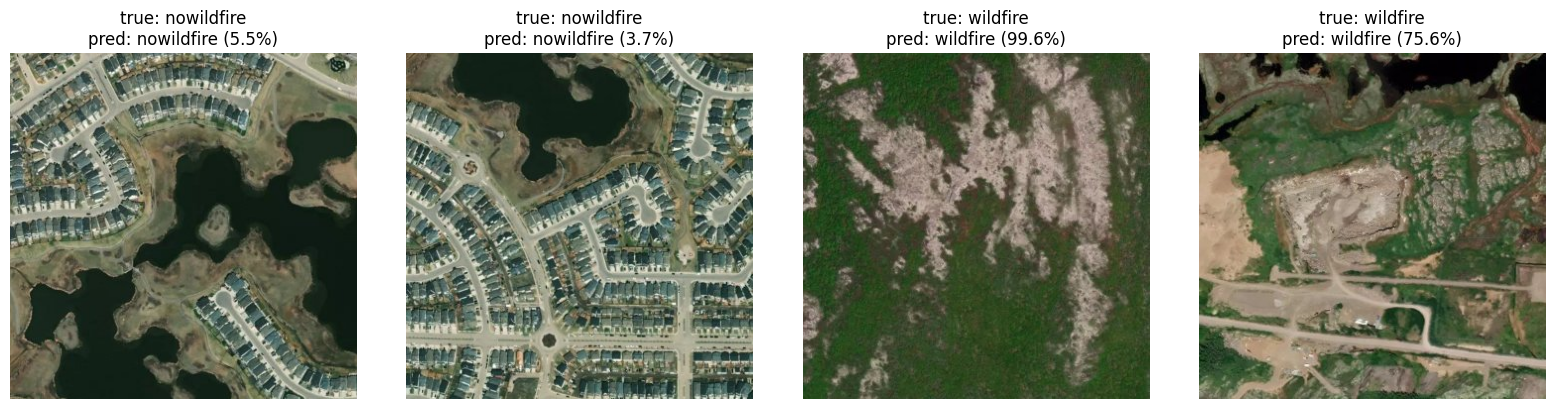

In [27]:
test_paths = (
    sorted((processed_dir / 'test' / 'nowildfire').glob('*.jpg'))[:2]
    + sorted((processed_dir / 'test' / 'wildfire').glob('*.jpg'))[:2]
)

fig, axes = plt.subplots(1, len(test_paths), figsize=(16, 4))
predictions = []
for axis, path in zip(axes, test_paths):
    batch, original = load_image_batch(path, image_size)
    probability = float(model(batch, training=False).numpy()[0, 0])
    predicted = 'wildfire' if probability >= threshold else 'nowildfire'
    truth = path.parent.name
    predictions.append({
        'file': path.name, 'truth': truth, 'prediction': predicted,
        'wildfire_probability': probability
    })
    axis.imshow(original)
    axis.set_title(f'true: {truth}\npred: {predicted} ({probability:.1%})')
    axis.axis('off')
plt.tight_layout()
predictions

## 5. Explain one decision with Grad-CAM

The explained class follows the validation-selected operational threshold. Pass `target_class=1` to ask specifically what increased the wildfire score. Warm regions contribute most strongly.

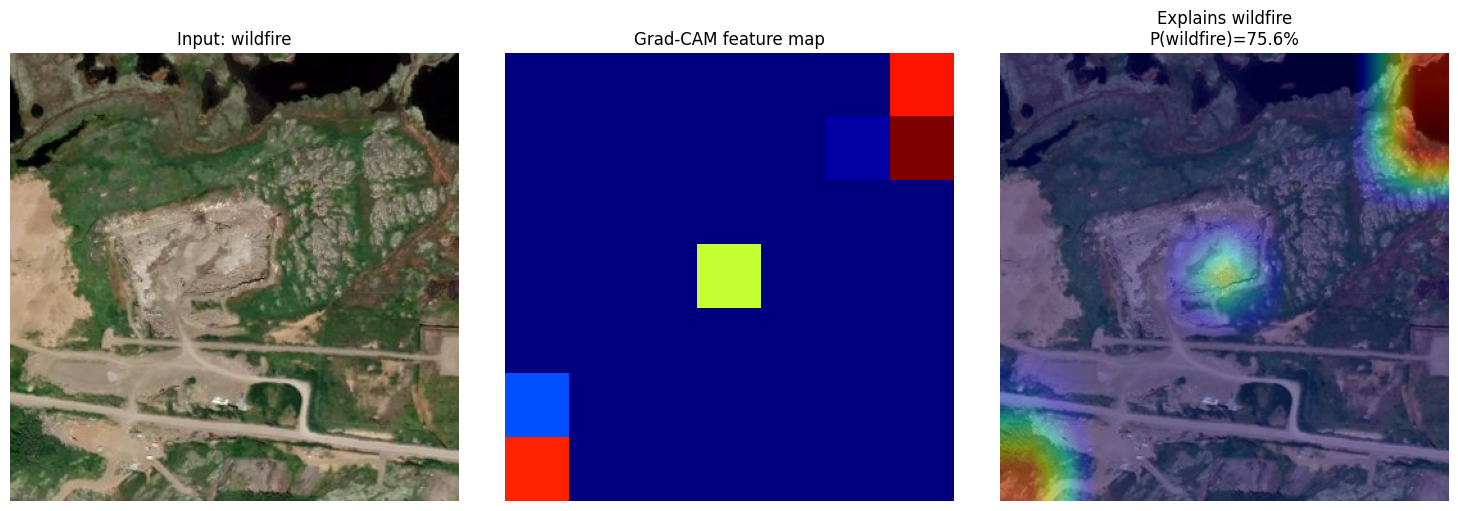

In [28]:
selected_path = test_paths[-1]
batch, original = load_image_batch(selected_path, image_size)
heatmap, probability, explained_class = make_gradcam_heatmap(
    batch, model, decision_threshold=threshold
)
overlay = overlay_heatmap(original, heatmap, alpha=0.4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original)
axes[0].set_title(f'Input: {selected_path.parent.name}')
axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title('Grad-CAM feature map')
axes[2].imshow(overlay)
axes[2].set_title(
    f'Explains {class_names[explained_class]}\nP(wildfire)={probability:.1%}'
)
for axis in axes:
    axis.axis('off')
plt.tight_layout()

## Interpretation checklist

- Compare correct and incorrect predictions from both classes.
- Look for consistent attention to visible fire/smoke cues rather than borders, text, water, clouds, or collection artifacts.
- Treat Grad-CAM as a sensitivity visualization, not a fire segmentation mask.
- Review PR-AUC, recall, F2, confusion matrix, and calibration together; accuracy alone is not an operational safety measure.
- Revalidate by geography, season, sensor, and time before deployment.